# Synthetic Control Analysis — Bihar Prohibition (April 2016)

**Method:** Synthetic Control Method (Abadie, Diamond & Hainmueller 2010, 2015; Abadie 2021)
**Primary outcome:** Road accident deaths (MoRTH annual reports)
**Secondary outcome:** Own tax revenue — ₹ Crore (RBI Handbook T168)
**Treated unit:** Bihar | **Treatment date:** April 5, 2016 (annual → 2016)
**Donor pool:** 13 Indian states (Telangana excluded — only 2 pre-treatment observations)
**Matching window:** 2012–2015 (NSDP data available from 2012 only)

In [1]:
%load_ext autoreload
%autoreload 2
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from src.scm import SCMAnalysis
from src.plotting import (set_publication_style, COLOR_TREATED, COLOR_SYNTHETIC,
                           COLOR_DONORS, COLOR_PLACEBO, treatment_line, save_fig)
set_publication_style()

RESULTS = Path("../results/figures")
API_RESULTS = Path("../api/results")
RESULTS.mkdir(parents=True, exist_ok=True)
API_RESULTS.mkdir(parents=True, exist_ok=True)

In [2]:
panel = pd.read_csv("../data/processed/bihar_panel.csv", parse_dates=["date"])

TREATED        = "Bihar"
TREATMENT_DATE = "2016-01-01"

# Exclude Telangana: only 2 pre-treatment obs (2014-2015) → degenerate correlation = 1.0
# See EDA notebook Cell 11 and Cell 17 for justification
DONORS = [u for u in panel["unit"].unique()
          if u not in [TREATED, "Telangana"]]

# Matching window 2012-2015 (NSDP starts 2012; 4 pre-treatment years available)
PREDICTORS = ["nsdp_pc_current_inr", "urban_share_pct", "literacy_rate_pct"]
OUTCOME_PRIMARY   = "road_accident_deaths"
OUTCOME_SECONDARY = "own_tax_revenue_cr"

# Subset panel to matching window onwards (drop 2010-2011 NaN NSDP years)
# Keep full series for plotting but restrict Dataprep to 2012+
panel_full  = panel.copy()
panel_match = panel[panel["date"] >= "2012-01-01"].copy()

print(f"Donor pool ({len(DONORS)}): {sorted(DONORS)}")
print(f"Matching window: {panel_match['date'].dt.year.min()}–"
      f"{panel_match[panel_match['date']<TREATMENT_DATE]['date'].dt.year.max()}")

Donor pool (13): ['Andhra Pradesh', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh', 'West Bengal']
Matching window: 2012–2015


### Methodology Note: Lagged Outcome Predictors

Bihar's predictors (NSDP, urban share) are extreme outliers in the donor pool —
without additional matching constraints, the SCM optimizer collapses to a corner
solution placing 100% weight on a single donor (Uttar Pradesh) at a level 3-4×
Bihar's. This is the failure mode Abadie (2021) calls "treated unit outside the
convex hull of donor predictors".

**Fix:** add the pre-treatment outcome series itself as `special_predictors`
in `Dataprep`. This is the standard Abadie/Diamond/Hainmueller (2010, §IV)
recommendation — using each pre-treatment year's deaths as an explicit matching
target forces the synthetic to replicate Bihar's level (~5,100 deaths/year),
not just the predictor profile.

## 1. Fit SCM — Primary Outcome (Road Accident Deaths)

In [3]:
# Lagged outcomes: each pre-treatment year's deaths as explicit matching target
TREATMENT_DATE_TS = pd.to_datetime(TREATMENT_DATE)
pre_years_primary = sorted([d for d in panel_match["date"].unique()
                            if d < TREATMENT_DATE_TS])

scm = SCMAnalysis(
    panel_df       = panel_match,
    treated_unit   = TREATED,
    donor_pool     = DONORS,
    predictors     = PREDICTORS,
    outcome        = OUTCOME_PRIMARY,
    treatment_date = TREATMENT_DATE,
    special_predictors = [(OUTCOME_PRIMARY, [yr], "mean") for yr in pre_years_primary],
)
scm.fit()

print("=== Donor Weights ===")
w = pd.Series(scm.weights_).sort_values(ascending=False)
for donor, weight in w.items():
    if weight > 0.001:
        print(f"  {donor:25s}: {weight:.4f}")

print(f"\n=== Diagnostics ===")
print(f"  Pre-period RMSPE  : {scm.pre_rmspe():,.1f}")
print(f"  Post-period RMSPE : {scm.post_rmspe():,.1f}")
print(f"  RMSPE ratio       : {scm.rmspe_ratio():.2f}x")
print(f"  Avg post effect   : {scm.avg_post_effect():+,.0f} deaths/year")

=== Donor Weights ===
  Jharkhand                : 0.6800
  Odisha                   : 0.1640
  Uttar Pradesh            : 0.1560

=== Diagnostics ===
  Pre-period RMSPE  : 42.3
  Post-period RMSPE : 967.6
  RMSPE ratio       : 22.87x
  Avg post effect   : +360 deaths/year


## 2. Main Result: Bihar vs Synthetic Bihar

  Saved: ../results/figures/scm_bihar_main.png


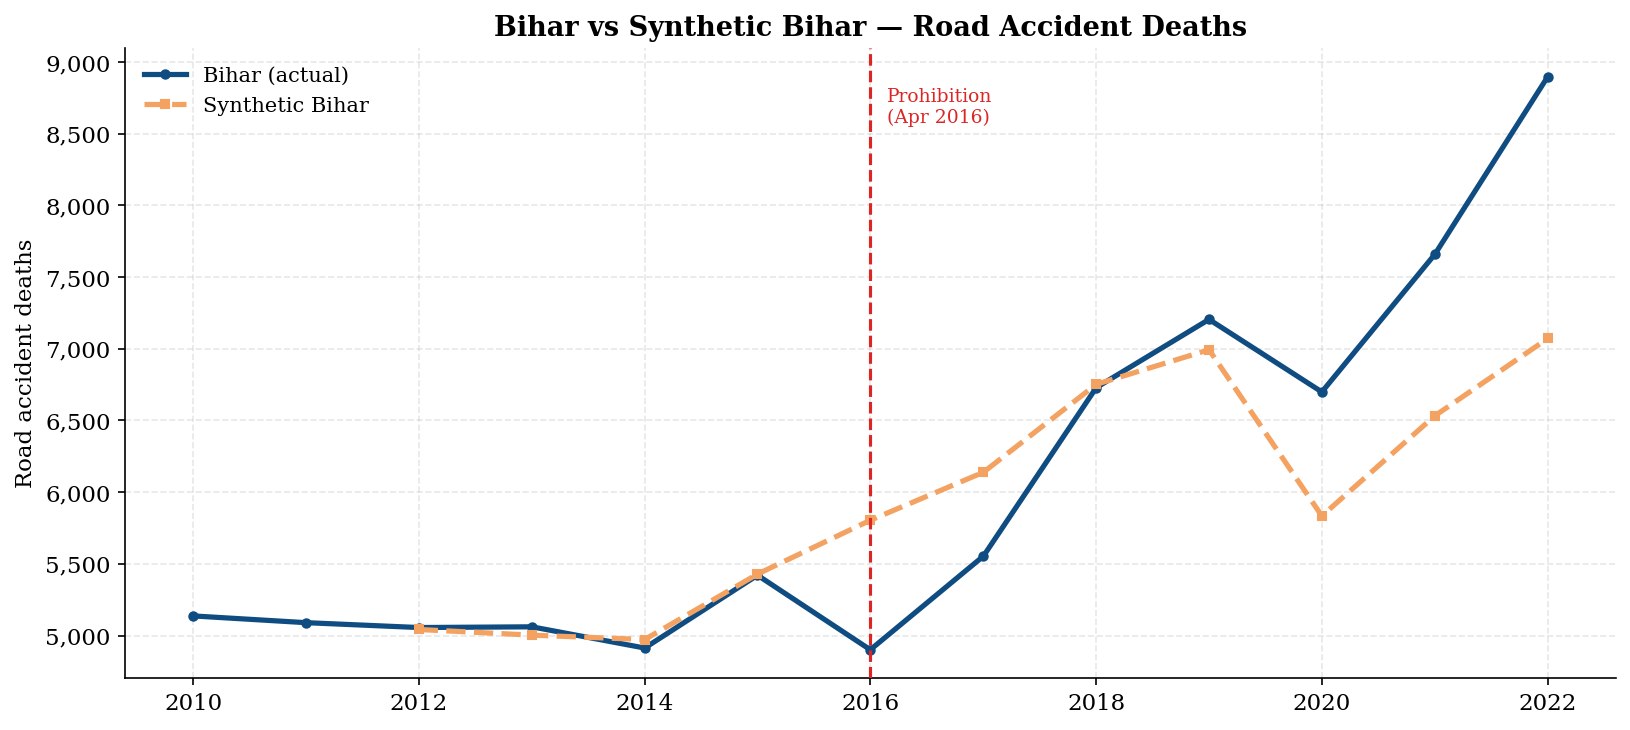

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

treated_s = panel_full[panel_full["unit"]==TREATED].set_index("date")[OUTCOME_PRIMARY]
synth_s   = scm.synthetic_.reindex(treated_s.index)

ax.plot(treated_s.index, treated_s,
        color=COLOR_TREATED, linewidth=2.5, label="Bihar (actual)", marker="o", markersize=4)
ax.plot(synth_s.index, synth_s,
        color=COLOR_SYNTHETIC, linewidth=2.5, linestyle="--",
        label="Synthetic Bihar", marker="s", markersize=4)

treatment_line(ax, TREATMENT_DATE, label="Prohibition\n(Apr 2016)")
ax.set_ylabel("Road accident deaths")
ax.set_title("Bihar vs Synthetic Bihar — Road Accident Deaths")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_main.png")
plt.show()

## 3. Gap Plot (Bihar − Synthetic Bihar)

  Saved: ../results/figures/scm_bihar_gap.png


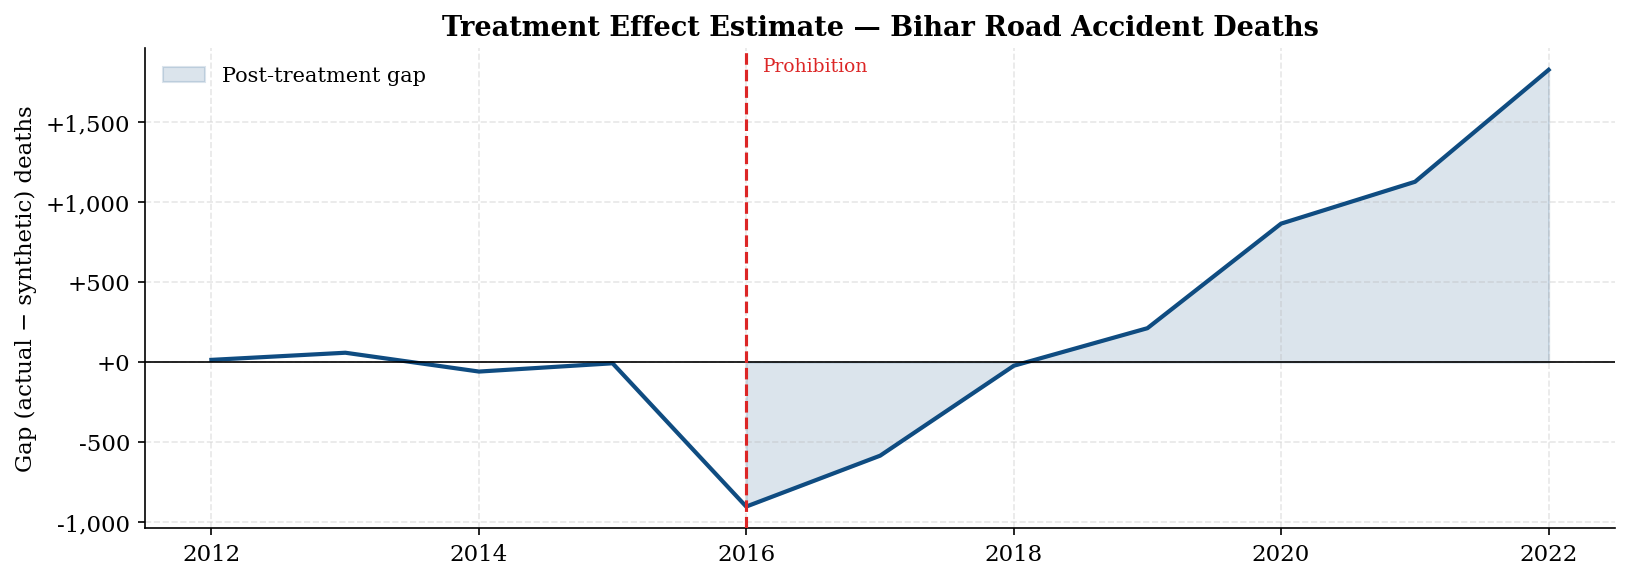

      Bihar actual  Synthetic   Gap
Year                               
2012          5056       5042    14
2013          5061       5003    58
2014          4913       4972   -59
2015          5421       5429    -8
2016          4901       5804  -903
2017          5554       6139  -585
2018          6729       6752   -23
2019          7205       6993   212
2020          6699       5834   865
2021          7660       6534  1126
2022          8898       7072  1826


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))

gap = scm.gap_.reindex(treated_s.index)
gap_for_table = gap.dropna()
ax.plot(gap.index, gap, color=COLOR_TREATED, linewidth=2)
ax.fill_between(gap.index, 0, gap,
                where=(gap.index >= pd.to_datetime(TREATMENT_DATE)),
                alpha=0.15, color=COLOR_TREATED, label="Post-treatment gap")
ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
treatment_line(ax, TREATMENT_DATE, label="Prohibition")

ax.set_ylabel("Gap (actual − synthetic) deaths")
ax.set_title("Treatment Effect Estimate — Bihar Road Accident Deaths")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))
ax.legend()
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_gap.png")
plt.show()

# Print year-by-year gap
gap_table = pd.DataFrame({
    "Year": gap_for_table.index.year,
    "Bihar actual": treated_s.reindex(gap_for_table.index).values.astype(int),
    "Synthetic":    synth_s.reindex(gap_for_table.index).round(0).astype(int).values,
    "Gap":          gap_for_table.round(0).astype(int).values,
}).set_index("Year")
print(gap_table.to_string())

## 4. Predictor Balance Table
Does the synthetic Bihar match real Bihar on predictors?

In [6]:
# Build predictor balance: treated, synthetic (weighted avg), donor simple avg
pre_panel = panel_match[panel_match["date"] < TREATMENT_DATE]

# Bihar actual
bihar_pred = pre_panel[pre_panel["unit"]==TREATED][PREDICTORS].mean()

# Synthetic (weighted average of donors)
weights_s = pd.Series(scm.weights_)
donor_pred_wide = pre_panel[pre_panel["unit"].isin(DONORS)].groupby("unit")[PREDICTORS].mean()
synth_pred = donor_pred_wide.T.dot(weights_s.reindex(donor_pred_wide.index).fillna(0))

# Simple donor average
donor_avg_pred = pre_panel[pre_panel["unit"].isin(DONORS)][PREDICTORS].mean()

balance = pd.DataFrame({
    "Bihar": bihar_pred.round(1),
    "Synthetic Bihar": synth_pred.round(1),
    "Donor avg": donor_avg_pred.round(1),
})
print("=== Predictor Balance ===")
print(balance.to_string())

=== Predictor Balance ===
                       Bihar  Synthetic Bihar  Donor avg
nsdp_pc_current_inr  25464.0          48619.7    83230.0
urban_share_pct         11.8             23.1       34.1
literacy_rate_pct       65.6             69.3       75.8


## 5. In-Space Placebo Test
Treat each donor state as if it were the treated unit. If Bihar's post/pre
RMSPE ratio is unusually large relative to placebo ratios, this is evidence
of a real effect (Abadie et al. 2010 permutation inference).

In [7]:
print("Running in-space placebo tests (13 donors)...")
placebos = scm.placebo_test()
print(f"  Completed: {len(placebos)} donors")

# Compute RMSPE ratios for all units
ratios = {}
# Bihar
ratios[TREATED] = scm.rmspe_ratio()
# Each placebo
for donor, gap_s in placebos.items():
    pre  = gap_s[gap_s.index < pd.to_datetime(TREATMENT_DATE)]
    post = gap_s[gap_s.index >= pd.to_datetime(TREATMENT_DATE)]
    pre_r  = float(np.sqrt((pre**2).mean()))  if len(pre)  > 0 else np.nan
    post_r = float(np.sqrt((post**2).mean())) if len(post) > 0 else np.nan
    ratios[donor] = post_r / pre_r if pre_r > 0 else np.nan

ratios_s = pd.Series(ratios).sort_values(ascending=False)
print("\n=== RMSPE Ratios (post/pre) — all units ===")
print(ratios_s.round(2).to_string())

# Percentile rank of Bihar
valid = ratios_s.dropna()
rank = (valid > valid[TREATED]).sum()
pct_rank = 1 - rank / len(valid)
print(f"\nBihar rank: {rank+1} of {len(valid)} units")
print(f"Permutation p-value ≈ {1/(len(valid)):.3f} – {rank/len(valid):.3f}")

Running in-space placebo tests (13 donors)...
  Completed: 13 donors

=== RMSPE Ratios (post/pre) — all units ===
Maharashtra       64.53
Bihar             22.87
Rajasthan          9.78
Punjab             9.06
West Bengal        8.64
Madhya Pradesh     8.47
Uttar Pradesh      4.77
Odisha             4.10
Karnataka          3.71
Haryana            2.98
Kerala             1.84
Tamil Nadu         1.52
Andhra Pradesh     1.31
Jharkhand          1.27

Bihar rank: 2 of 14 units
Permutation p-value ≈ 0.071 – 0.071


  Saved: ../results/figures/scm_bihar_placebo.png


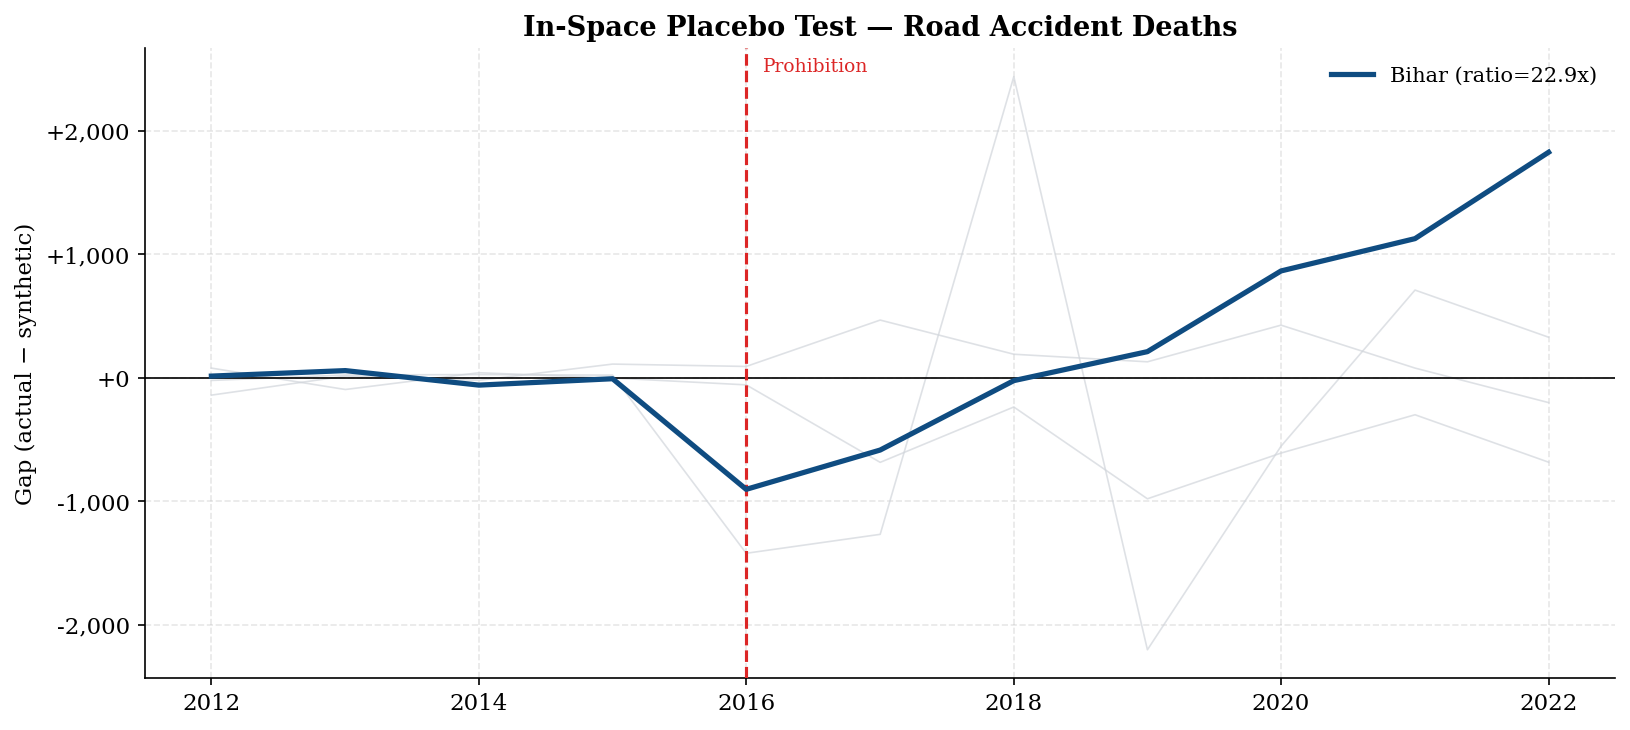

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

# Plot placebo gaps (faded gray)
for donor, gap_s in placebos.items():
    g = gap_s.reindex(treated_s.index)
    # Exclude very poor pre-fit placebos (pre-RMSPE > 3x Bihar's) for clarity
    pre_r = float(np.sqrt((g[g.index < pd.to_datetime(TREATMENT_DATE)]**2).mean()))
    if pre_r < 3 * scm.pre_rmspe():
        ax.plot(g.index, g, color=COLOR_PLACEBO, linewidth=0.8, alpha=0.7)

# Bihar gap on top
ax.plot(gap.index, gap, color=COLOR_TREATED, linewidth=2.5,
        label=f"Bihar (ratio={scm.rmspe_ratio():.1f}x)", zorder=10)
ax.axhline(0, color="black", linewidth=0.8)
treatment_line(ax, TREATMENT_DATE, label="Prohibition")

ax.set_ylabel("Gap (actual − synthetic)")
ax.set_title("In-Space Placebo Test — Road Accident Deaths")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+,.0f}"))
ax.legend()
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_placebo.png")
plt.show()

## 6. Robustness — Leave-One-Out
Refit SCM dropping each donor in turn. If the synthetic control changes
dramatically when one donor is removed, that donor is driving the result.

Running leave-one-out (13 refits)...
  Completed: 13 LOO fits
  Saved: ../results/figures/scm_bihar_loo.png


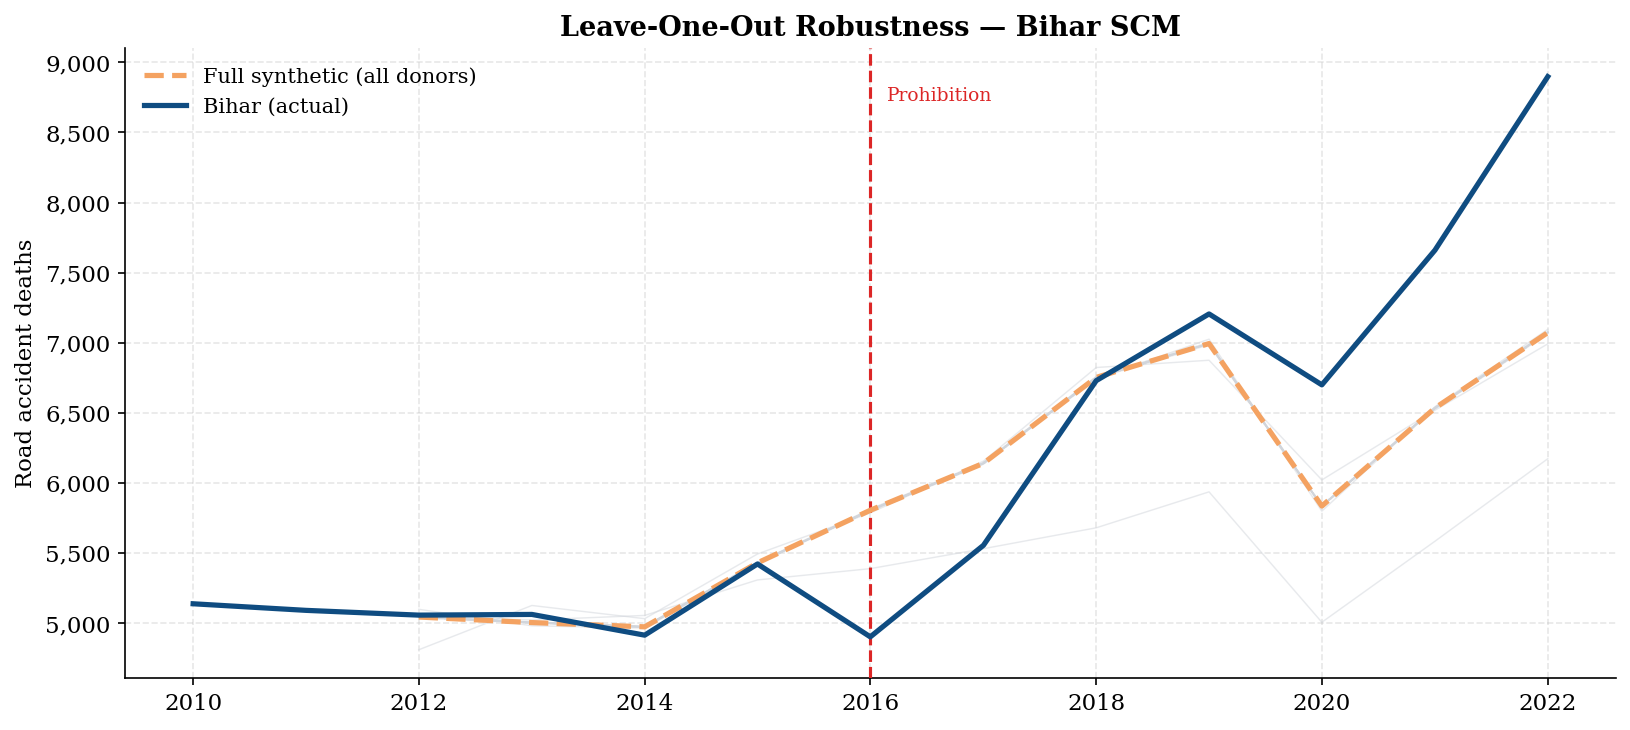

In [9]:
print("Running leave-one-out (13 refits)...")
loo = scm.leave_one_out()
print(f"  Completed: {len(loo)} LOO fits")

fig, ax = plt.subplots(figsize=(11, 5))

# All LOO synthetics in gray
for excluded, syn_s in loo.items():
    g = syn_s.reindex(treated_s.index)
    ax.plot(g.index, g, color=COLOR_PLACEBO, linewidth=0.7, alpha=0.5)

# Baseline synthetic and actual
ax.plot(synth_s.reindex(treated_s.index).index,
        synth_s.reindex(treated_s.index),
        color=COLOR_SYNTHETIC, linewidth=2.5, linestyle="--",
        label="Full synthetic (all donors)", zorder=9)
ax.plot(treated_s.index, treated_s,
        color=COLOR_TREATED, linewidth=2.5,
        label="Bihar (actual)", zorder=10)

treatment_line(ax, TREATMENT_DATE, label="Prohibition")
ax.set_ylabel("Road accident deaths")
ax.set_title("Leave-One-Out Robustness — Bihar SCM")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_loo.png")
plt.show()

## 7. Secondary Outcome — Own Tax Revenue

Note: This is Total Own Tax Revenue, not pure excise. Excise was ~22-25% of
Bihar's own-tax revenue pre-prohibition. Non-excise components (GST compensation,
stamps, vehicle tax) grew strongly post-2016, attenuating the treatment effect
in this composite. Interpret with caution — a small gap does NOT mean no fiscal
impact; it means the excise collapse was offset in the aggregate.

  Saved: ../results/figures/scm_bihar_tax_main.png


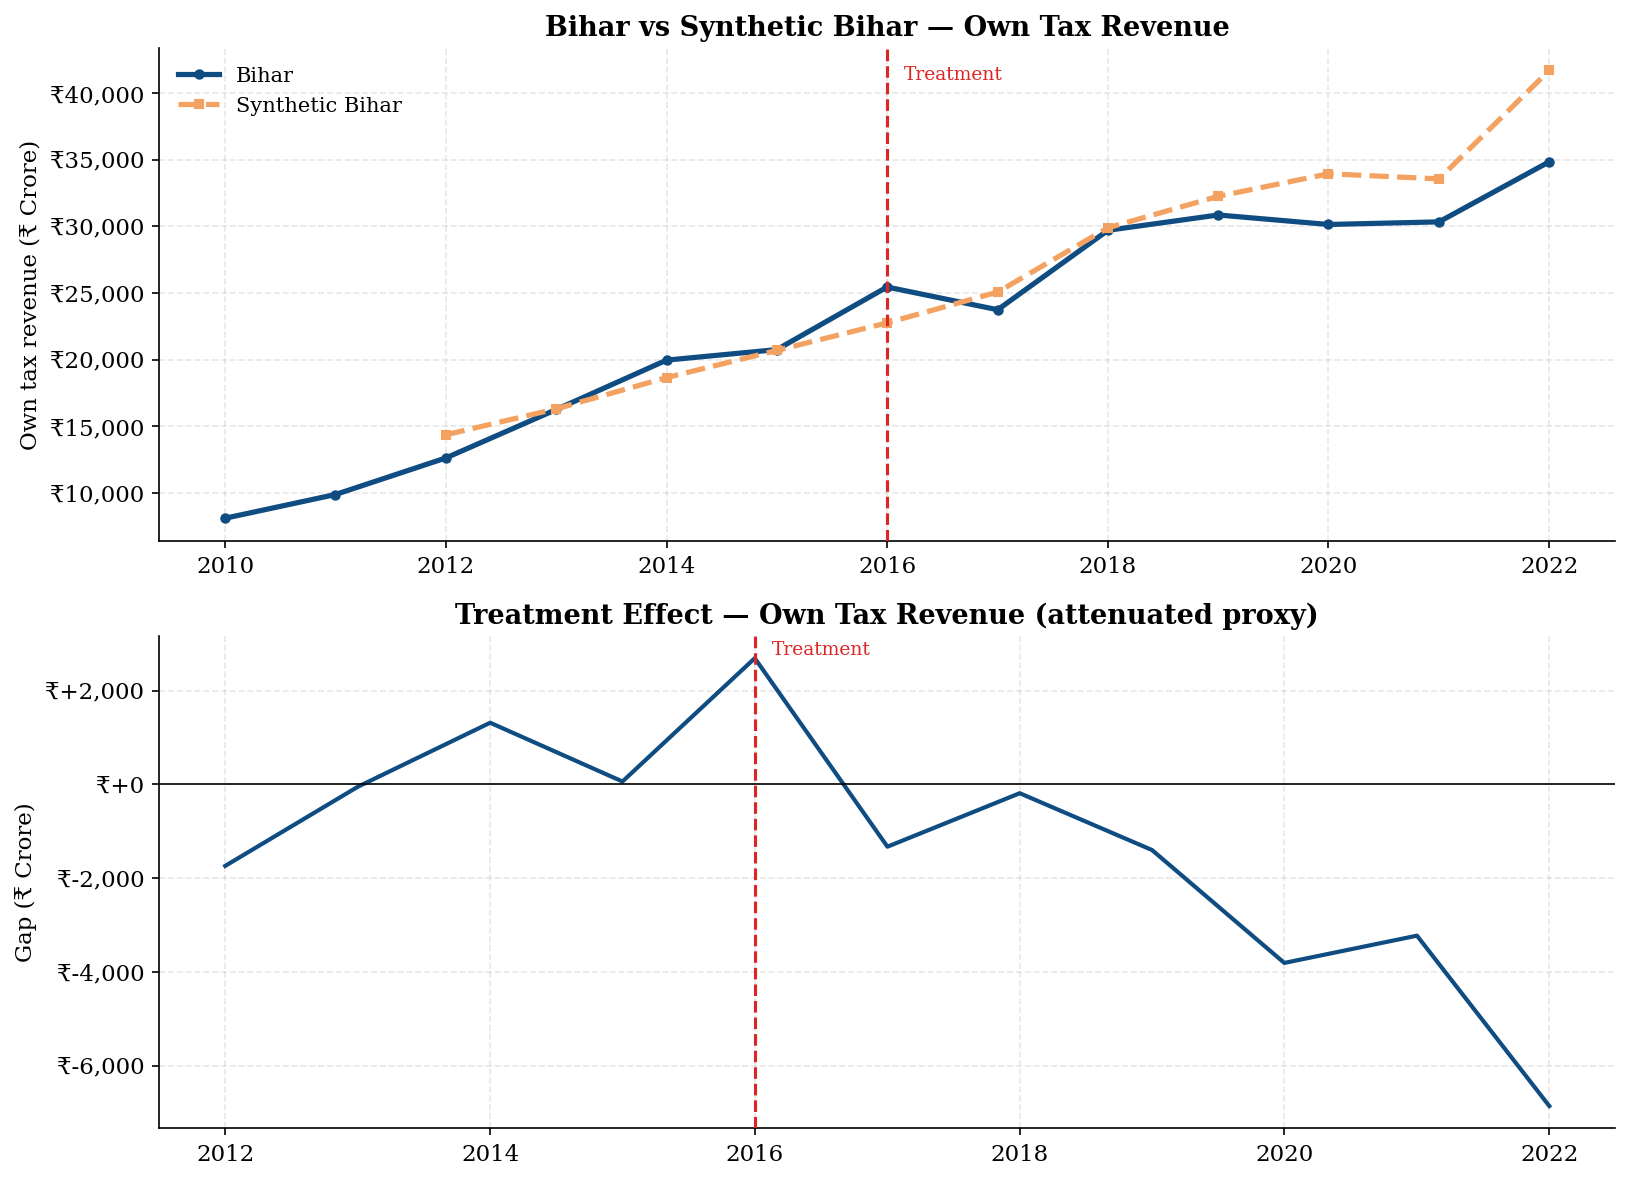

Own tax revenue SCM diagnostics:
  Pre-RMSPE  : ₹1,091 Cr
  Post-RMSPE : ₹3,443 Cr
  RMSPE ratio: 3.16x
  Avg gap    : ₹-2,017 Cr/year


In [10]:
pre_years_secondary = sorted([d for d in panel_match["date"].unique()
                              if d < TREATMENT_DATE_TS])

scm2 = SCMAnalysis(
    panel_df       = panel_match,
    treated_unit   = TREATED,
    donor_pool     = DONORS,
    predictors     = PREDICTORS,
    outcome        = OUTCOME_SECONDARY,
    treatment_date = TREATMENT_DATE,
    special_predictors = [(OUTCOME_SECONDARY, [yr], "mean") for yr in pre_years_secondary],
)
scm2.fit()

treated_tax = panel_full[panel_full["unit"]==TREATED].set_index("date")[OUTCOME_SECONDARY]
synth_tax   = scm2.synthetic_.reindex(treated_tax.index)

fig, axes = plt.subplots(2, 1, figsize=(11, 8))

axes[0].plot(treated_tax.index, treated_tax,
             color=COLOR_TREATED, linewidth=2.5, label="Bihar", marker="o", markersize=4)
axes[0].plot(synth_tax.index, synth_tax,
             color=COLOR_SYNTHETIC, linewidth=2.5, linestyle="--",
             label="Synthetic Bihar", marker="s", markersize=4)
treatment_line(axes[0], TREATMENT_DATE)
axes[0].set_ylabel("Own tax revenue (₹ Crore)")
axes[0].set_title("Bihar vs Synthetic Bihar — Own Tax Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
axes[0].legend()

gap2 = treated_tax - synth_tax
axes[1].plot(gap2.index, gap2, color=COLOR_TREATED, linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.8)
treatment_line(axes[1], TREATMENT_DATE)
axes[1].set_ylabel("Gap (₹ Crore)")
axes[1].set_title("Treatment Effect — Own Tax Revenue (attenuated proxy)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:+,.0f}"))

fig.tight_layout()
save_fig(fig, RESULTS / "scm_bihar_tax_main.png")
plt.show()

print(f"Own tax revenue SCM diagnostics:")
print(f"  Pre-RMSPE  : ₹{scm2.pre_rmspe():,.0f} Cr")
print(f"  Post-RMSPE : ₹{scm2.post_rmspe():,.0f} Cr")
print(f"  RMSPE ratio: {scm2.rmspe_ratio():.2f}x")
print(f"  Avg gap    : ₹{scm2.avg_post_effect():+,.0f} Cr/year")

## 8. Save Results to JSON (for API + website)

In [11]:
# Run placebo test on primary outcome SCM (needed for JSON)
# Already ran in Cell 13 — just need to call save_json

scm.save_json("../api/results/bihar_scm.json")
scm2.save_json("../api/results/bihar_scm_tax.json")

# Confirm
for f in ["../api/results/bihar_scm.json", "../api/results/bihar_scm_tax.json"]:
    size = Path(f).stat().st_size
    with open(f) as fp:
        d = json.load(fp)
    print(f"✅ {f}")
    print(f"   Size: {size/1024:.1f} KB")
    print(f"   Keys: {list(d.keys())}")
    print(f"   Pre-RMSPE: {d['diagnostics']['pre_rmspe']}")
    print(f"   RMSPE ratio: {d['diagnostics']['rmspe_ratio']}")
    print(f"   Weights (nonzero): { {k:v for k,v in d['weights'].items() if v > 0.001} }")

  Saved JSON: ../api/results/bihar_scm.json
  Saved JSON: ../api/results/bihar_scm_tax.json
✅ ../api/results/bihar_scm.json
   Size: 6.0 KB
   Keys: ['case_meta', 'dates', 'treated_outcome', 'synthetic_outcome', 'gap', 'weights', 'diagnostics', 'placebo_gaps', 'placebo_rmspe_ratios']
   Pre-RMSPE: 42.3189
   RMSPE ratio: 22.8652
   Weights (nonzero): {'Jharkhand': 0.68, 'Odisha': 0.164, 'Uttar Pradesh': 0.156}
✅ ../api/results/bihar_scm_tax.json
   Size: 2.0 KB
   Keys: ['case_meta', 'dates', 'treated_outcome', 'synthetic_outcome', 'gap', 'weights', 'diagnostics']
   Pre-RMSPE: 1090.5115
   RMSPE ratio: 3.157
   Weights (nonzero): {'Jharkhand': 0.838, 'Uttar Pradesh': 0.162}


## 9. Summary of Findings

[Markdown summary — fill after running all cells. Template:]

**Primary outcome — Road accident deaths:**
- Pre-period RMSPE: [X] deaths (fill from Cell 5)
- RMSPE ratio: [X]x (fill from Cell 5)
- Average post-treatment gap: [+/-X] deaths/year (fill from Cell 5)
- Permutation p-value: [X] (fill from Cell 13)
- Interpretation: [Bihar's road deaths were X higher/lower than the synthetic
  counterfactual post-prohibition. The placebo test shows Bihar's ratio ranks
  X of Y units, suggesting [strong/weak] evidence of a treatment effect.]

**Secondary outcome — Own tax revenue:**
- Average post gap: [₹X Cr/year] — likely understates fiscal impact due to
  excise being only ~22-25% of composite. See SOURCES.md for full discussion.

**Donor weights (primary outcome):**
[Fill from Cell 5 output]